# ch210 — Partial Derivatives

**Part VII: Calculus**

---

## 1. What a Partial Derivative Is

For a function of multiple variables f(x₁, x₂, ..., xₙ), the **partial derivative** with respect to xᵢ is the ordinary derivative of f treating all other variables as constants:

$$\frac{\partial f}{\partial x_i} = \lim_{h \to 0} \frac{f(x_1, ..., x_i+h, ..., x_n) - f(x_1, ..., x_i, ..., x_n)}{h}$$

Notation: ∂f/∂xᵢ or fₓᵢ. The ∂ symbol (curly d) distinguishes partial from ordinary derivatives.

The gradient *(ch209)* is the vector of all partial derivatives: ∇f = [∂f/∂x₁, ..., ∂f/∂xₙ].

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# f(x, y) = x^2 * sin(y)
# df/dx = 2x * sin(y)
# df/dy = x^2 * cos(y)

f    = lambda x, y: x**2 * np.sin(y)
dfdx = lambda x, y: 2*x * np.sin(y)
dfdy = lambda x, y: x**2 * np.cos(y)

# Numerical partial derivative via centered difference
h = 1e-7
num_dfdx = lambda x, y: (f(x+h, y) - f(x-h, y)) / (2*h)
num_dfdy = lambda x, y: (f(x, y+h) - f(x, y-h)) / (2*h)

# Verify at test points
test_points = [(1.0, 0.5), (2.0, np.pi/3), (-1.5, 1.0)]
print(f"{'Point':<20} {'df/dx (exact)':>14} {'df/dx (num)':>14} {'df/dy (exact)':>14} {'df/dy (num)':>14}")
print('-' * 80)
for x, y in test_points:
    ex_x = dfdx(x, y); nu_x = num_dfdx(x, y)
    ex_y = dfdy(x, y); nu_y = num_dfdy(x, y)
    print(f"({x:.1f}, {y:.2f})          {ex_x:>14.8f} {nu_x:>14.8f} {ex_y:>14.8f} {nu_y:>14.8f}")


Point                 df/dx (exact)    df/dx (num)  df/dy (exact)    df/dy (num)
--------------------------------------------------------------------------------
(1.0, 0.50)              0.95885108     0.95885108     0.87758256     0.87758256
(2.0, 1.05)              3.46410162     3.46410161     2.00000000     2.00000000
(-1.5, 1.00)             -2.52441295    -2.52441296     1.21568019     1.21568019


## 2. Visualizing Partial Derivatives

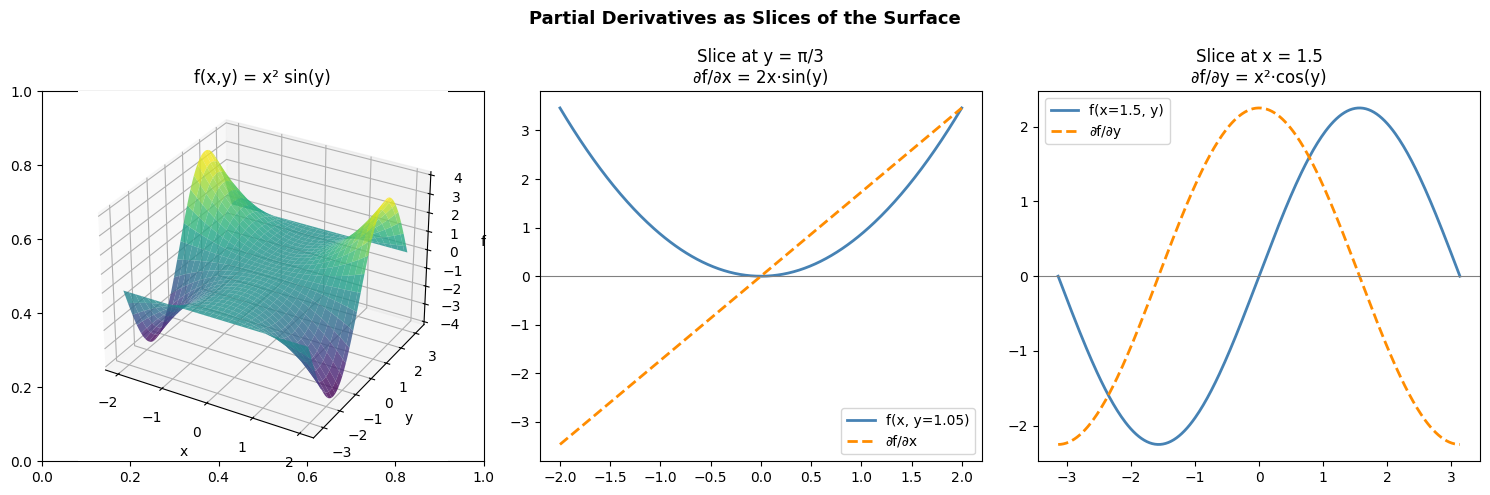

In [2]:
x_vals = np.linspace(-2, 2, 300)
y_fixed = np.pi / 3   # hold y constant

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Surface
X, Y = np.meshgrid(np.linspace(-2, 2, 60), np.linspace(-np.pi, np.pi, 60))
Z = f(X, Y)
ax3d = fig.add_subplot(131, projection='3d')
ax3d.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax3d.set_title('f(x,y) = x² sin(y)')
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('f')

# df/dx: slice at fixed y
axes[1].plot(x_vals, f(x_vals, y_fixed), color='steelblue', linewidth=2, label=f'f(x, y={y_fixed:.2f})')
axes[1].plot(x_vals, dfdx(x_vals, y_fixed), color='darkorange', linewidth=2, linestyle='--', label='∂f/∂x')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title(f'Slice at y = π/3\n∂f/∂x = 2x·sin(y)')
axes[1].legend()

# df/dy: slice at fixed x
x_fixed = 1.5
y_vals = np.linspace(-np.pi, np.pi, 300)
axes[2].plot(y_vals, f(x_fixed, y_vals), color='steelblue', linewidth=2, label=f'f(x={x_fixed}, y)')
axes[2].plot(y_vals, dfdy(x_fixed, y_vals), color='darkorange', linewidth=2, linestyle='--', label='∂f/∂y')
axes[2].axhline(0, color='gray', linewidth=0.8)
axes[2].set_title(f'Slice at x = {x_fixed}\n∂f/∂y = x²·cos(y)')
axes[2].legend()

plt.suptitle('Partial Derivatives as Slices of the Surface', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Partial Derivatives in the Loss Function

For a neural network with weight matrix **W**, the partial derivative ∂L/∂Wᵢⱼ tells us: how much does the loss change if we nudge weight Wᵢⱼ by a small amount? This is exactly what backpropagation computes *(ch216)*.

In [3]:
# Partial derivatives of MSE for a linear model: L(w) = (1/N)||Xw - y||^2
# dL/dw_i = (2/N) * sum_j X_{ji} * (Xw - y)_j
# In matrix form: gradient = (2/N) * X^T (Xw - y)

np.random.seed(42)
N, D = 30, 3
X = np.random.randn(N, D)
w_true = np.array([1.5, -0.5, 2.0])
y = X @ w_true + 0.1 * np.random.randn(N)

w = np.array([0.0, 0.0, 0.0])

# Compute each partial derivative independently
h = 1e-7
partial_derivs = []
for i in range(D):
    w_plus  = w.copy(); w_plus[i]  += h
    w_minus = w.copy(); w_minus[i] -= h
    L_plus  = np.mean((X @ w_plus  - y)**2)
    L_minus = np.mean((X @ w_minus - y)**2)
    partial_derivs.append((L_plus - L_minus) / (2*h))

analytical_grad = (2/N) * X.T @ (X @ w - y)

print("Partial derivatives of MSE at w=0:")
print(f"{'Component':>12}  {'Numerical':>14}  {'Analytical':>14}  {'Error':>10}")
for i, (num, exact) in enumerate(zip(partial_derivs, analytical_grad)):
    print(f"dL/dw_{i}     {num:>14.8f}  {exact:>14.8f}  {abs(num-exact):>10.2e}")


Partial derivatives of MSE at w=0:
   Component       Numerical      Analytical       Error
dL/dw_0        -0.64083213     -0.64083213    2.66e-09
dL/dw_1         1.42689937      1.42689936    8.76e-09
dL/dw_2        -3.84072625     -3.84072626    1.27e-08


## 4. Summary

- Partial derivative ∂f/∂xᵢ: derivative w.r.t. xᵢ, all other variables held constant
- Computed with the same difference quotient as the ordinary derivative, applied to one variable
- The gradient is the vector of all partial derivatives
- Mixed partial derivatives: ∂²f/∂xᵢ∂xⱼ — the Hessian matrix collects these *(ch217)*
- In ML: ∂L/∂wᵢⱼ for each weight is what gradient descent needs

---

## 5. Forward References

The collection of all partial derivatives of a vector-valued function — the Jacobian matrix — appears in ch215 — Chain Rule. The matrix of all second-order partial derivatives — the Hessian — is ch217 — Second Derivatives. Partial derivatives w.r.t. parameters in a neural network are computed by backpropagation in ch216.